In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime as dt

In [2]:
df=pd.read_csv(r"D:\Ahmed\Ahmed\projects\Vehicle-Insurance-Fraud-Detection-End2End\Data\car_insurance_fraud_dataset.csv")
df.head(5)

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,...,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,...,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,...,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,...,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,...,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


In [3]:
df["insured_occupation"].value_counts()

insured_occupation
Teacher       3799
Doctor        3778
Manager       3777
Clerk         3773
Technician    3758
Lawyer        3725
Sales         3702
Engineer      3688
Name: count, dtype: int64

In [54]:
df.columns


Index(['policy_id', 'policy_state', 'policy_deductible',
       'policy_annual_premium', 'insured_age', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'police_report_available',
       'claim_amount', 'total_claim_amount', 'fraud_reported'],
      dtype='object')

In [4]:
cols_to_drop = [
    "policy_id",
    "incident_city",
    "insured_occupation",
    "insured_hobbies",
    "authorities_contacted"
]

df.drop(columns=cols_to_drop, inplace=True, errors="ignore")

In [5]:
df.shape

(30000, 19)

In [6]:
date_cols = ["policy_bind_date", "incident_date"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
if "policy_bind_date" in df.columns and "incident_date" in df.columns:
    df["policy_duration_days"] = (df["incident_date"] - df["policy_bind_date"]).dt.days        

In [7]:
if "total_claim_amount" in df.columns and "policy_annual_premium" in df.columns:
    df["claim_to_premium_ratio"] = df["total_claim_amount"] / (df["policy_annual_premium"] + 1)

if "injury_claim" in df.columns and "total_claim_amount" in df.columns:
    df["injury_ratio"] = df["injury_claim"] / (df["total_claim_amount"] + 1)

if "property_claim" in df.columns and "total_claim_amount" in df.columns:
    df["property_ratio"] = df["property_claim"] / (df["total_claim_amount"] + 1)

In [8]:
if "number_of_vehicles_involved" in df.columns:
    df["multi_vehicle"] = (df["number_of_vehicles_involved"] > 1).astype(int)

In [9]:
if "total_claim_amount" in df.columns:
    df["claim_severity"] = pd.cut(
        df["total_claim_amount"],
        bins=3,
        labels=[0,1,2]
    )

In [10]:
df.drop(columns=["incident_date"], inplace=True)

In [11]:
df.shape

(30000, 21)

In [9]:
df.isnull().sum()


policy_state                   0
policy_deductible              0
policy_annual_premium          0
insured_age                    0
insured_sex                    0
insured_education_level        0
incident_date                  0
incident_type                  0
collision_type                 0
incident_severity              0
incident_state                 0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
bodily_injuries                0
witnesses                      0
police_report_available        0
claim_amount                   0
total_claim_amount             0
fraud_reported                 0
claim_to_premium_ratio         0
multi_vehicle                  0
claim_severity                 0
dtype: int64

In [10]:
df.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,incident_date,incident_type,collision_type,incident_severity,...,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,claim_to_premium_ratio,multi_vehicle,claim_severity
0,GA,400,1430.78,74,OTHER,High School,2024-06-13,Parked Car,Front,Total Loss,...,1,4,0,Yes,8161.36,11677.60,Y,8.156002,0,1
1,PA,300,854.49,74,MALE,College,2025-03-23,Vehicle Theft,Rear,Total Loss,...,3,4,5,No,18561.79,18027.81,N,21.073081,1,2
2,MI,400,1247.28,28,OTHER,PhD,2025-01-26,Parked Car,Unknown,Total Loss,...,4,4,1,No,10734.61,10375.59,N,8.311909,1,1
3,CA,600,622.42,37,MALE,PhD,2024-06-03,Parked Car,Rear,Total Loss,...,3,3,5,No,13188.92,14204.34,N,22.784543,1,1
4,MI,700,1458.17,31,OTHER,PhD,2024-05-21,Single Vehicle Collision,Side,Minor Damage,...,4,2,4,No,21864.69,24038.84,N,16.474324,1,2


In [12]:
df["fraud_reported"].value_counts()

fraud_reported
N    26560
Y     3440
Name: count, dtype: int64

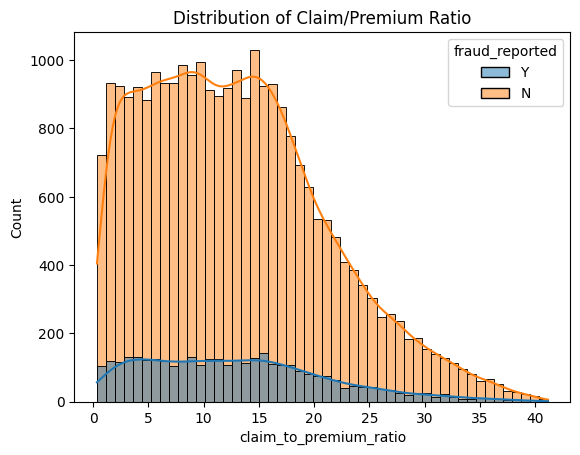

In [11]:
sns.histplot(data=df, x="claim_to_premium_ratio", hue="fraud_reported", bins=50, kde=True)
plt.title("Distribution of Claim/Premium Ratio")
plt.show()

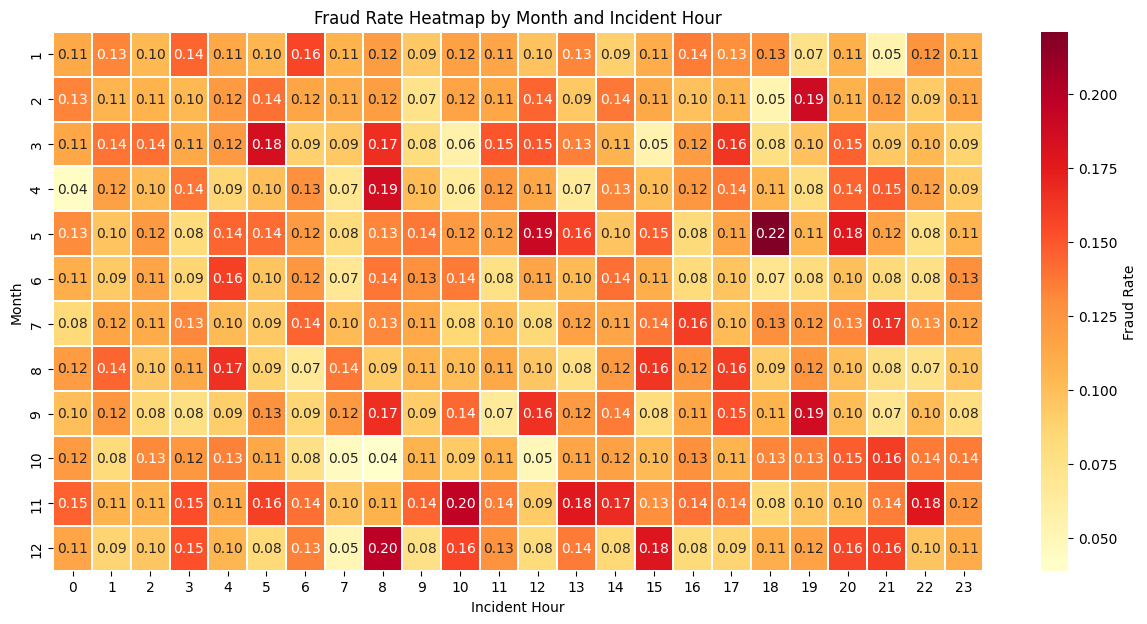

In [12]:
# Fraud rate by hour and month (risk heatmap)
if "df_viz" not in globals():
    df_viz = df.copy()
    df_viz["fraud_flag"] = df_viz["fraud_reported"].map({"Y": 1, "N": 0}).astype("int8")
    safe_premium = df_viz["policy_annual_premium"].replace(0, np.nan)
    df_viz["claim_to_premium_ratio"] = (df_viz["total_claim_amount"] / safe_premium).fillna(0)

fraud_heat = (
    df_viz.groupby(["month", "incident_hour_of_the_day"])["fraud_flag"]
    .mean()
    .unstack(fill_value=0)
)

plt.figure(figsize=(15, 7))
sns.heatmap(fraud_heat, cmap="YlOrRd", linewidths=0.2, cbar_kws={"label": "Fraud Rate"}, annot=True, fmt=".2f")
plt.title("Fraud Rate Heatmap by Month and Incident Hour")
plt.xlabel("Incident Hour")
plt.ylabel("Month")
plt.show()

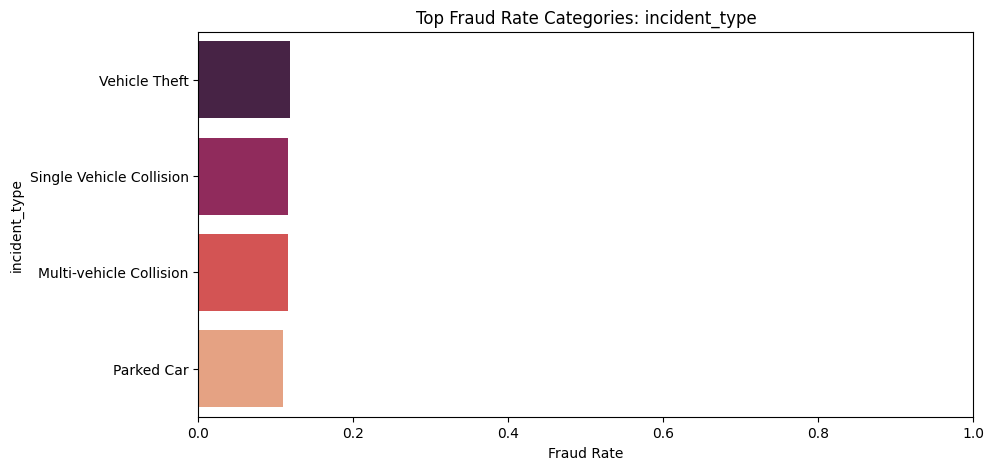

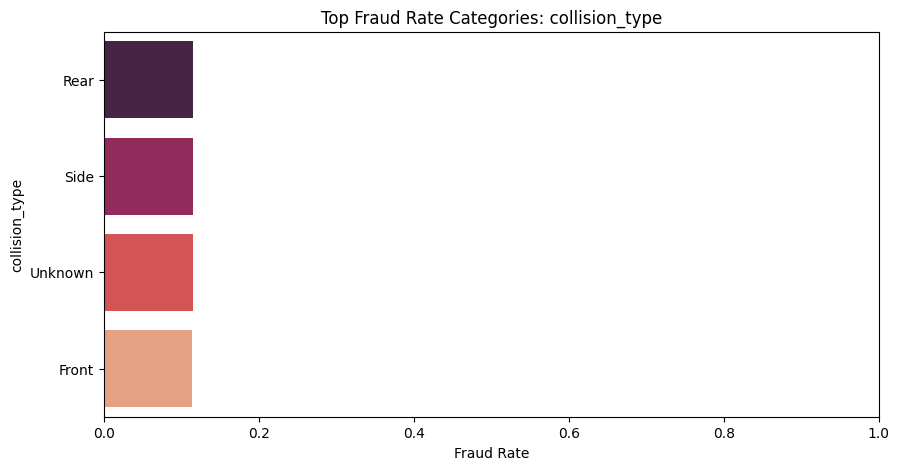

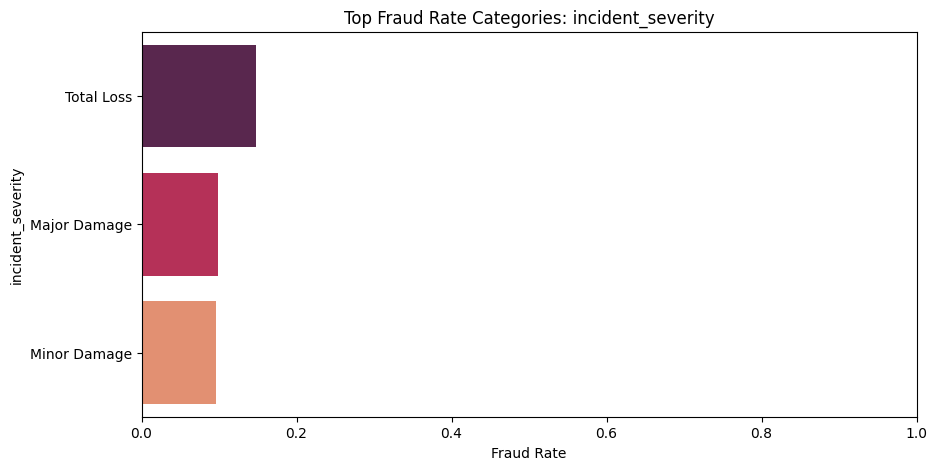

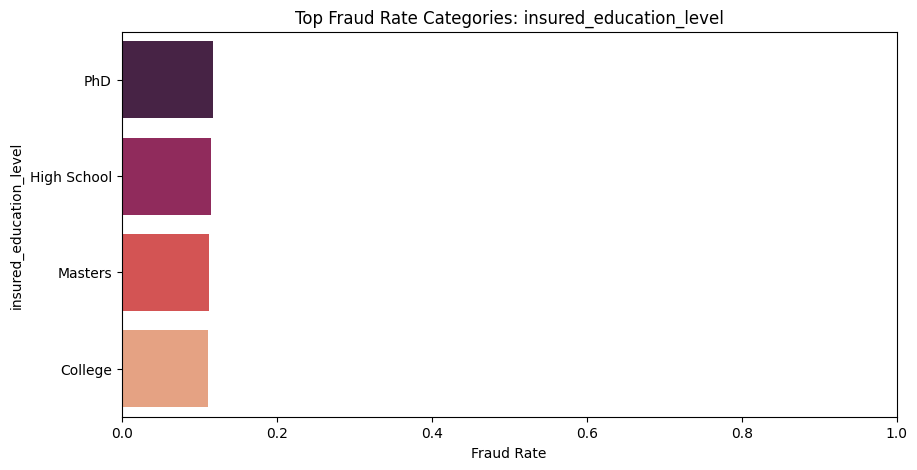

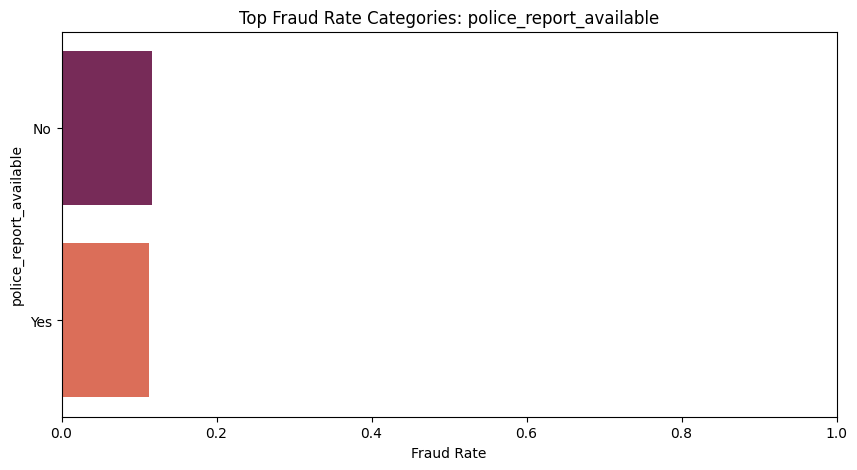

In [13]:
# Top risky categories by fraud rate
if "df_viz" not in globals():
    df_viz = df.copy()
    df_viz["fraud_flag"] = df_viz["fraud_reported"].map({"Y": 1, "N": 0}).astype("int8")

cat_cols = [
    "incident_type",
    "collision_type",
    "incident_severity",
    "insured_education_level",
    "police_report_available",
]

for c in cat_cols:
    if c in df_viz.columns:
        rate = df_viz.groupby(c)["fraud_flag"].mean().sort_values(ascending=False).head(10)

        plt.figure(figsize=(10, 5))
        sns.barplot(x=rate.values, y=rate.index, hue=rate.index, legend=False, palette="rocket")
        plt.title(f"Top Fraud Rate Categories: {c}")
        plt.xlabel("Fraud Rate")
        plt.ylabel(c)
        plt.xlim(0, 1)
        plt.show()

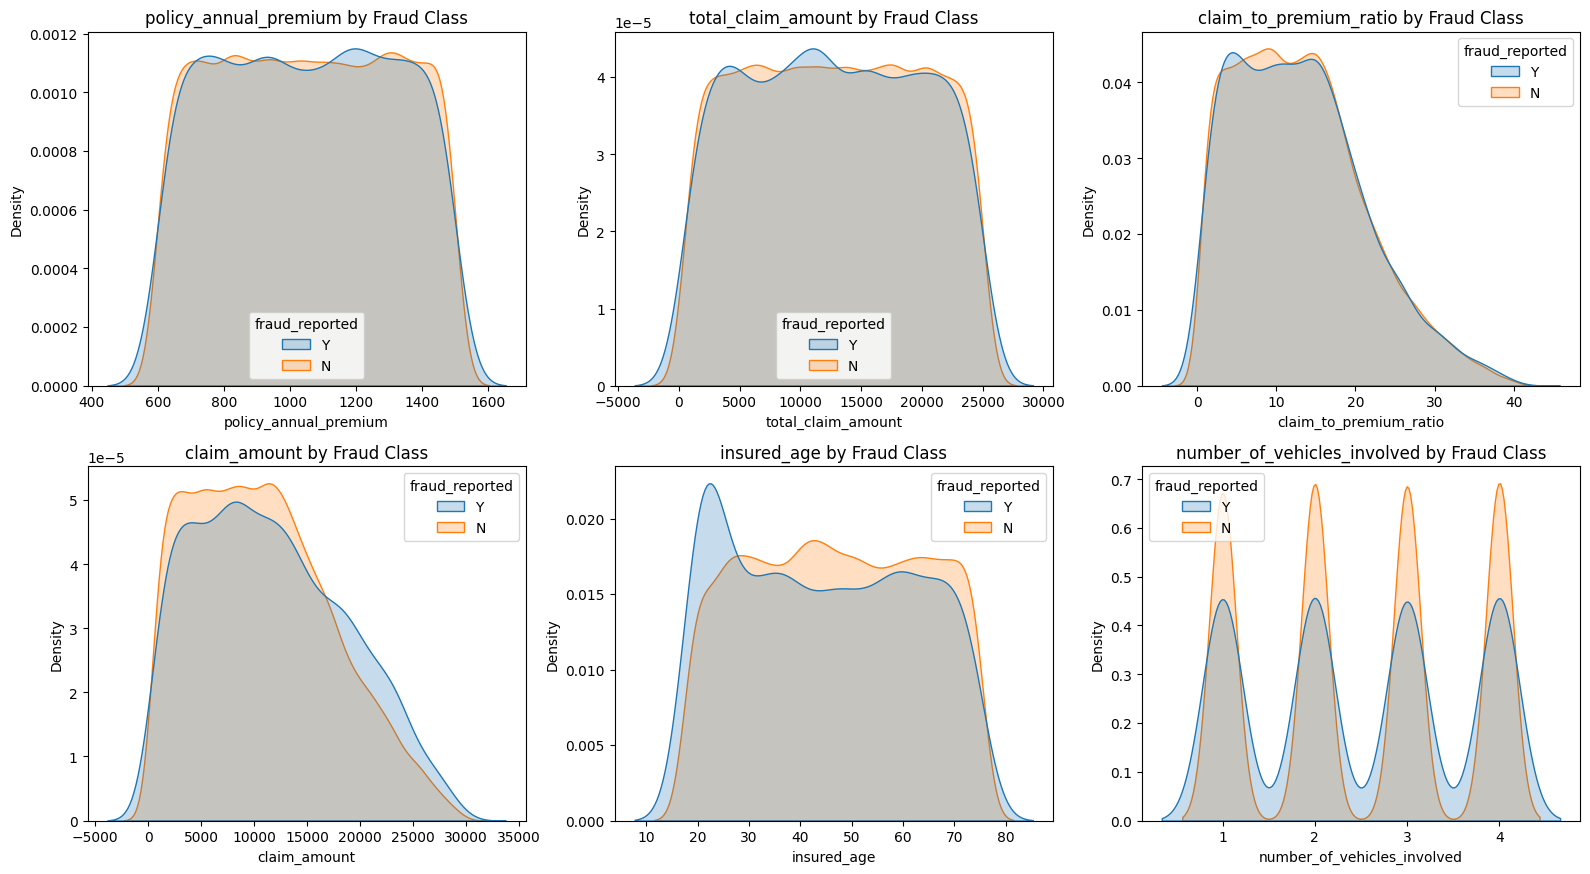

In [14]:
# Numeric behavior comparison by fraud class

if "df_viz" not in globals():
    df_viz = df.copy()

safe_premium = df_viz["policy_annual_premium"].replace(0, np.nan)
df_viz["claim_to_premium_ratio"] = (df_viz["total_claim_amount"] / safe_premium).fillna(0)

candidate_cols = [
    "policy_annual_premium",
    "total_claim_amount",
    "claim_to_premium_ratio",
    "claim_amount",
    "insured_age",
    "number_of_vehicles_involved",
]
num_cols = [c for c in candidate_cols if c in df_viz.columns]

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df_viz, x=col, hue="fraud_reported", fill=True, common_norm=False, ax=axes[i])
    axes[i].set_title(f"{col} by Fraud Class")

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

C:\Users\teffa\AppData\Local\Temp\ipykernel_16672\1898630034.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x=feature,palette='mako'
C:\Users\teffa\AppData\Local\Temp\ipykernel_16672\1898630034.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x=feature,palette='mako'
C:\Users\teffa\AppData\Local\Temp\ipykernel_16672\1898630034.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x=feature,palette='mako'
C:\Users\teffa\AppData\Local\Temp\ipykernel_16672\1898630034.py:6: FutureWarning: 

Passing `palette` without

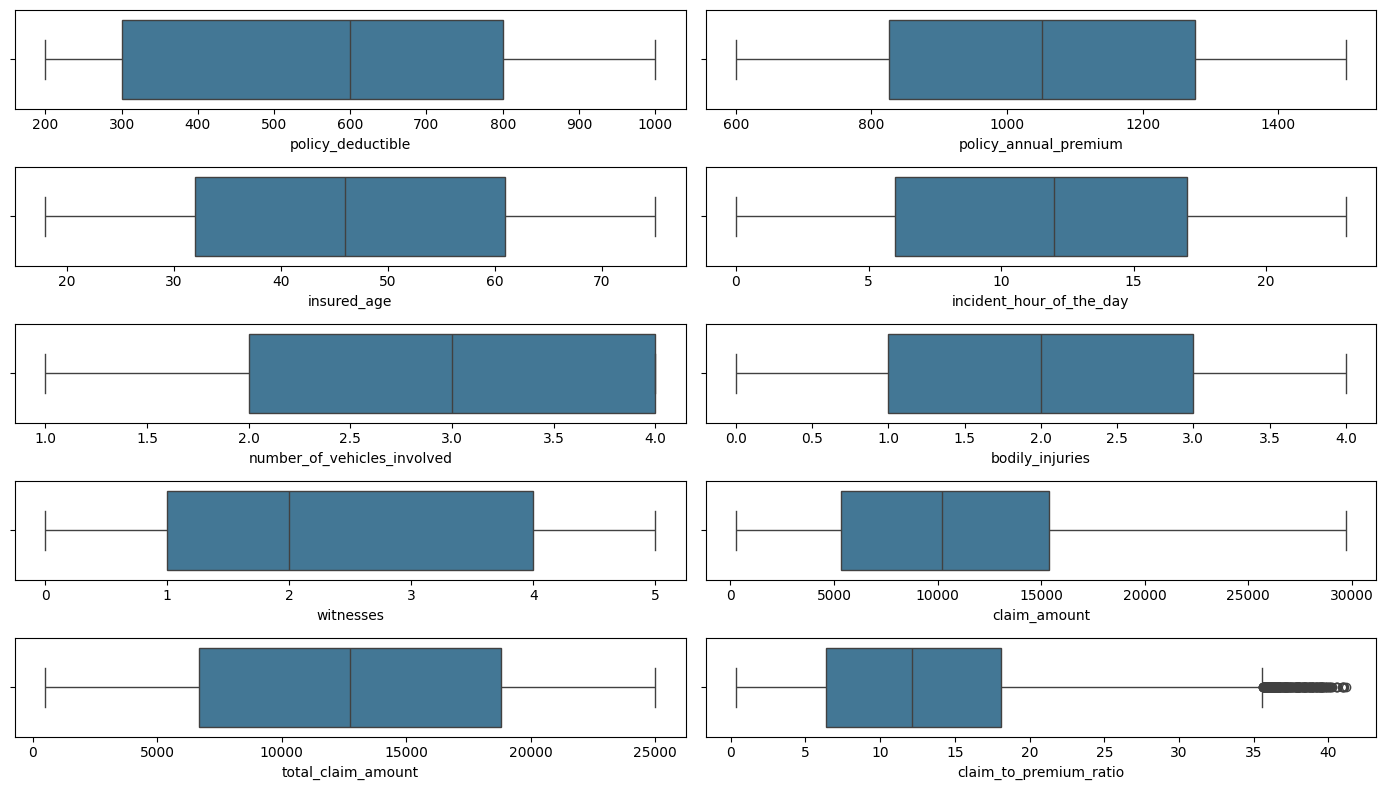

In [10]:
plt.figure(figsize=(14, 8))
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
for i, feature in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols)//2 + len(numerical_cols)%2, 2, i + 1)
    sns.boxplot(data=df,x=feature,palette='mako' 
    )
plt.tight_layout()
plt.show()

In [13]:
def cap_outliers_iqr(df, feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[feature] = df[feature].clip(lower, upper)

for feature in ["claim_to_premium_ratio"]:
    cap_outliers_iqr(df, feature)

C:\Users\teffa\AppData\Local\Temp\ipykernel_16672\1898630034.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x=feature,palette='mako'
C:\Users\teffa\AppData\Local\Temp\ipykernel_16672\1898630034.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x=feature,palette='mako'
C:\Users\teffa\AppData\Local\Temp\ipykernel_16672\1898630034.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x=feature,palette='mako'
C:\Users\teffa\AppData\Local\Temp\ipykernel_16672\1898630034.py:6: FutureWarning: 

Passing `palette` without

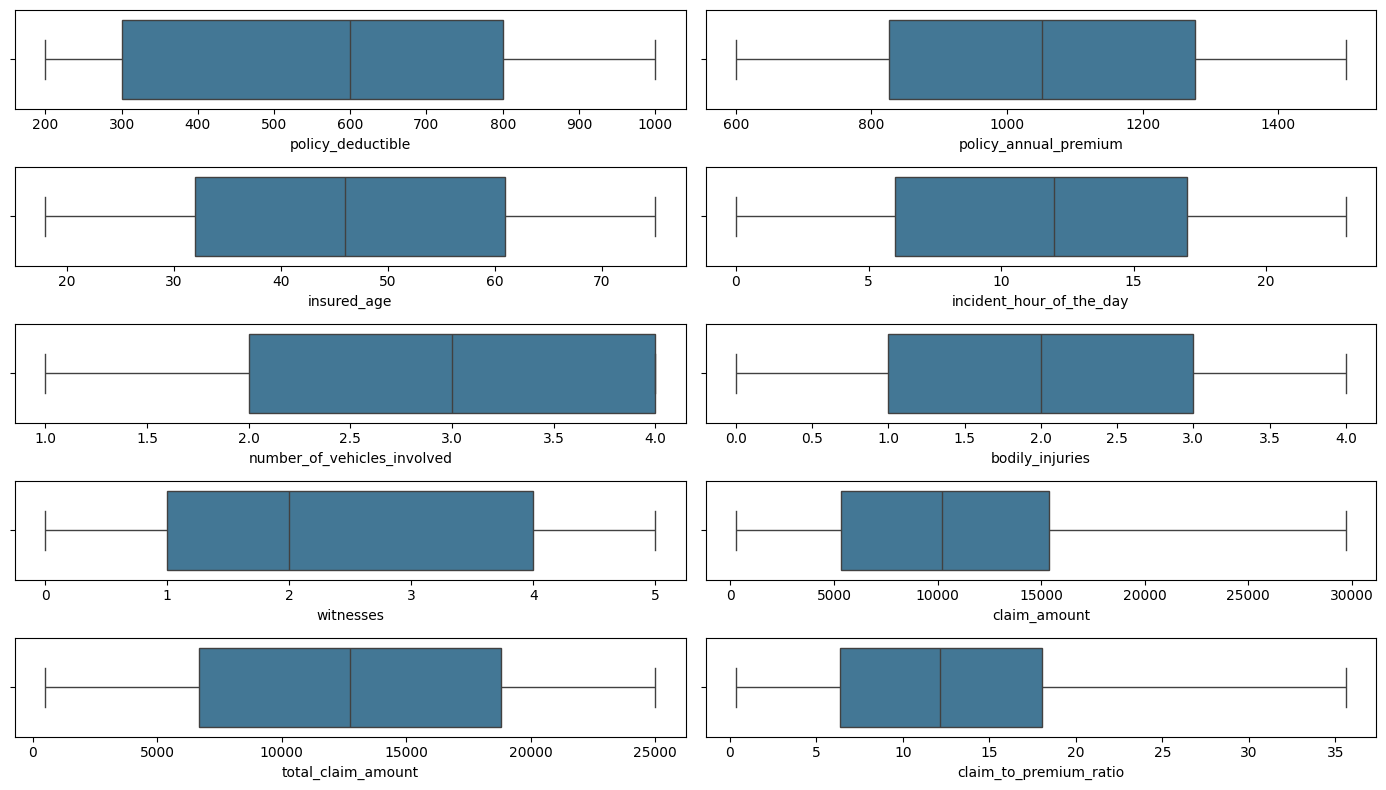

In [12]:
plt.figure(figsize=(14, 8))
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
for i, feature in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols)//2 + len(numerical_cols)%2, 2, i + 1)
    sns.boxplot(data=df,x=feature,palette='mako' 
    )
plt.tight_layout()
plt.show()

In [13]:
df.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_type,collision_type,...,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,month,day,claim_to_premium_ratio
0,GA,400,1430.78,74,OTHER,High School,Manager,reading,Parked Car,Front,...,1,4,0,Yes,8161.36,11677.60,Y,6,13,8.161702
1,PA,300,854.49,74,MALE,College,Lawyer,chess,Vehicle Theft,Rear,...,3,4,5,No,18561.79,18027.81,N,3,23,21.097743
2,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,Parked Car,Unknown,...,4,4,1,No,10734.61,10375.59,N,1,26,8.318573
3,CA,600,622.42,37,MALE,PhD,Teacher,yachting,Parked Car,Rear,...,3,3,5,No,13188.92,14204.34,N,6,3,22.821150
4,MI,700,1458.17,31,OTHER,PhD,Sales,reading,Single Vehicle Collision,Side,...,4,2,4,No,21864.69,24038.84,N,5,21,16.485622


In [14]:
y = df["fraud_reported"]
X = df.drop("fraud_reported", axis=1)

In [15]:
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include=["object", "category", "bool"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

X[num_cols] = scaler.fit_transform(X[num_cols])

In [17]:
y = y.astype(str).str.strip().str.lower()

y = y.map({
    "y": 1,
    "yes": 1,
    "true": 1,
    "n": 0,
    "no": 0,
    "false": 0
})

In [18]:
df_final = X.copy()
df_final["fraud_reported"] = y

In [79]:
y.value_counts

<bound method IndexOpsMixin.value_counts of 0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
29995   NaN
29996   NaN
29997   NaN
29998   NaN
29999   NaN
Name: fraud_reported, Length: 30000, dtype: float64>

In [75]:
df_final["fraud_reported"].value_counts()

Series([], Name: count, dtype: int64)

In [19]:
from sklearn.model_selection import train_test_split

X = df_final.drop("fraud_reported", axis=1)
y = df_final["fraud_reported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# y = df["fraud_reported"]
# X = df.drop("fraud_reported", axis=1)
# categorical_cols = X.select_dtypes(include=["object"]).columns
# numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

# #Encoding
# X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# #Scaling
# scaler = StandardScaler()
# X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

# #mapping 
# y = y.map({"Y":1, "N":0, "Yes":1, "No":0,"True":1, "False":0})

# df_final = X_encoded.copy()
# df_final["fraud_reported"] = y

# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, classification_report

# 📊 تقسيم الداتا
# X = df_final.drop("fraud_reported", axis=1)
# y = df_final["fraud_reported"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

In [16]:
X_train

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,incident_date,incident_type,collision_type,incident_severity,...,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,claim_to_premium_ratio,multi_vehicle,claim_severity
23204,-0.171229,-0.250723,-1.534745,0.269332,-1.234630,-1.344245,2024-10-23,-0.449680,1.34899,1.217097,...,0.071780,-0.455814,0.001700,-1.466722,-0.993422,2.542712,1.582802,2.793811,0.570986,1.225951
12495,-1.569679,0.148624,0.325193,1.346693,-0.008704,-1.344245,2024-04-11,1.333114,-0.44119,-0.004275,...,-0.798284,0.439813,1.418326,-0.881126,1.006622,1.670733,1.585588,0.999406,0.570986,1.225951
3579,-1.220067,0.947317,0.970932,-1.346709,-1.234630,-0.449076,2024-04-19,0.441717,0.45390,-1.225646,...,-1.088306,1.335439,1.418326,0.875661,1.006622,-1.430004,-1.554092,-1.424225,0.570986,-1.230618
25114,1.227222,-0.650070,-1.548918,-1.705829,1.217222,0.446092,2024-07-14,0.441717,-0.44119,-1.225646,...,0.796834,1.335439,1.418326,-0.295531,-0.993422,0.408012,0.184123,1.076992,0.570986,-0.002334
134,0.877609,-0.250723,-1.466607,0.568599,1.217222,-0.449076,2025-10-20,-0.449680,-1.33628,-0.004275,...,-1.523338,-0.455814,0.001700,-0.881126,1.006622,0.027480,-0.305056,0.357904,0.570986,-0.002334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618,0.178384,0.148624,0.052908,-0.508762,-1.234630,1.341261,2025-02-23,-0.449680,-1.33628,-1.225646,...,1.521888,-1.351441,-0.706613,1.461257,-0.993422,-0.411818,0.391717,0.199659,-1.751355,-0.002334
14190,1.576835,1.746011,0.379158,-0.987588,-1.234630,0.446092,2025-04-05,-1.341077,-1.33628,-0.004275,...,-1.523338,-1.351441,-1.414926,0.290065,-0.993422,-0.958952,-1.170503,-1.111588,-1.751355,-1.230618
18934,-1.220067,0.947317,-0.081371,-0.149641,-0.008704,-0.449076,2025-02-17,0.441717,0.45390,-1.225646,...,1.521888,1.335439,-0.706613,-0.881126,1.006622,-0.387819,-0.757964,-0.707614,0.570986,-1.230618
25945,-0.870454,0.148624,0.190606,0.389039,-0.008704,-1.344245,2025-03-26,1.333114,0.45390,1.217097,...,-1.668349,1.335439,-0.706613,1.461257,-0.993422,1.041045,0.605833,0.309909,0.570986,1.225951


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 📊 تقسيم الداتا
X = df_final.drop("fraud_reported", axis=1)
y = df_final["fraud_reported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🧠 Import Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# 📦 نخزن الموديلات في Dictionary
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=1.0
    ),

    "Naive Bayes": GaussianNB(),  # مفيهوش class_weight

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",   # مهم مع imbalance
        metric="minkowski"
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=10,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    )
}





# 🚀 Training + Evaluation
results = {}

for name, model in models.items():
    print(f"\n🔹 {name}")
    
    # تدريب
    model.fit(X_train, y_train)
    
    # توقع
    y_pred = model.predict(X_test)
    
    # تقييم
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


🔹 Logistic Regression


d:\Ahmed\Ahmed\projects\Vehicle-Insurance-Fraud-Detection-End2End\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.7708
              precision    recall  f1-score   support

           0       0.90      0.83      0.87      5312
           1       0.18      0.28      0.22       688

    accuracy                           0.77      6000
   macro avg       0.54      0.56      0.54      6000
weighted avg       0.82      0.77      0.79      6000


🔹 Naive Bayes
Accuracy: 0.4052
              precision    recall  f1-score   support

           0       0.88      0.38      0.53      5312
           1       0.11      0.61      0.19       688

    accuracy                           0.41      6000
   macro avg       0.50      0.50      0.36      6000
weighted avg       0.80      0.41      0.49      6000


🔹 KNN
Accuracy: 0.8828
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      5312
           1       0.22      0.01      0.02       688

    accuracy                           0.88      6000
   macro avg       0.55      0.50      0.48      6000
w

In [14]:
X_train.shape

(24000, 100)

In [20]:
def objective_lr(trial):
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import recall_score, accuracy_score

    C = trial.suggest_float("C", 0.01, 10)
    threshold = trial.suggest_float("threshold", 0.3, 0.6)

    model = LogisticRegression(
        C=C,
        max_iter=1000,
        class_weight="balanced"
    )

    model.fit(X_train, y_train)

    y_probs = model.predict_proba(X_test)[:,1]
    y_pred = (y_probs > threshold).astype(int)

    recall = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # 🔥 penalty بدل ما نرمي الحل
    score = 0.6 * recall + 0.4 * acc

    if acc < 0.6:
        score *= 0.5   # يقلل السكور بدل ما يلغيه

    return score

In [21]:
def objective_dt(trial):
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.metrics import recall_score, accuracy_score

    threshold = trial.suggest_float("threshold", 0.3, 0.6)

    model = DecisionTreeClassifier(
        max_depth=trial.suggest_int("max_depth", 3, 15),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    y_probs = model.predict_proba(X_test)[:,1]
    y_pred = (y_probs > threshold).astype(int)

    recall = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    score = 0.7 * recall + 0.3 * acc

    if acc < 0.6:
        score *= 0.7

    return score

In [22]:
def objective_rf(trial):
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import recall_score, accuracy_score

    threshold = trial.suggest_float("threshold", 0.3, 0.6)

    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 150),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_probs = model.predict_proba(X_test)[:,1]
    y_pred = (y_probs > threshold).astype(int)

    recall = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    score = 0.7 * recall + 0.3 * acc

    if acc < 0.6:
        score *= 0.7

    return score

In [23]:
def objective_xgb(trial):
    from xgboost import XGBClassifier
    from sklearn.metrics import recall_score, accuracy_score

    threshold = trial.suggest_float("threshold", 0.3, 0.6)

    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

    model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 150),
        max_depth=trial.suggest_int("max_depth", 3, 6),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2),
        subsample=trial.suggest_float("subsample", 0.7, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 1.0),
        gamma=trial.suggest_float("gamma", 0, 2),
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train, y_train)

    y_probs = model.predict_proba(X_test)[:,1]
    y_pred = (y_probs > threshold).astype(int)

    recall = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    score = 0.7 * recall + 0.3 * acc

    if acc < 0.6:
        score *= 0.7

    return score

In [27]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 5.6 MB/s eta 0:00:18
   ---------------------------------------- 0.8/100.2 MB 2.0 MB/s eta 0:00:51
    --------------------------------------- 1.8/100.2 MB 3.7 MB/s eta 0:00:27
   - -------------------------------------- 2.6/100.2 MB 3.6 MB/s eta 0:00:28
   - -------------------------------------- 3.4/100.2 MB 3.6 MB/s eta 0:00:27
   - -------------------------------------- 3.9/100.2 MB 3.6 MB/s eta 0:00:28
   - -------------------------------------- 4.7/100.2 MB 3.5 MB/s eta 0:00:28
   -- ------------------------------------- 5.5/100.2 MB 3.5 MB/s eta 0:00:28
   -- ------------------------------------- 6.0/100.2 MB 3.4 MB/s eta 0:00:28
   -- ------------------------------------- 6.8/100.2 MB 3.4 MB/s eta 0:00:28
   --- ------------------------------------ 7.6/100.2 MB 3.5 MB/s eta 0:00:27
   --- ------------------------------------ 8.1/100.2 MB 3.4 MB/s eta 0

In [28]:
def objective_catboost(trial):
    from catboost import CatBoostClassifier
    from sklearn.metrics import recall_score, accuracy_score

    threshold = trial.suggest_float("threshold", 0.3, 0.6)

    model = CatBoostClassifier(
        iterations=trial.suggest_int("iterations", 100, 300),
        depth=trial.suggest_int("depth", 4, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1, 10),
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
        random_state=42,
        verbose=0
    )

    model.fit(X_train, y_train)

    y_probs = model.predict_proba(X_test)[:,1]
    y_pred = (y_probs > threshold).astype(int)

    recall = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # 🔥 نفس ال scoring اللي كنا شغالين عليه
    score = 0.7 * recall + 0.3 * acc

    if acc < 0.6:
        score *= 0.7

    return score

In [29]:
import optuna
import gc

studies = {}

objectives = {
    "Logistic": objective_lr,
    "DecisionTree": objective_dt,
    "RandomForest": objective_rf,
    "XGBoost": objective_xgb,
    "CatBoost": objective_catboost
}

for name, func in objectives.items():
    print(f"\n🔍 Tuning {name}")

    study = optuna.create_study(direction="maximize")
    study.optimize(func, n_trials=50, show_progress_bar=True)

    studies[name] = study

    print("Best Recall:", study.best_value)
    print("Best Params:", study.best_params)

    gc.collect()

[I 2026-04-05 19:07:10,394] A new study created in memory with name: no-name-a31f5c1f-9729-41ff-854d-bb6ddd8aa4b4



🔍 Tuning Logistic


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-05 19:07:10,459] Trial 0 finished with value: 0.5763697674418604 and parameters: {'C': 6.967498966169349, 'threshold': 0.5259184366521787}. Best is trial 0 with value: 0.5763697674418604.
[I 2026-04-05 19:07:10,502] Trial 1 finished with value: 0.3252104651162791 and parameters: {'C': 6.36544578276702, 'threshold': 0.31676165568426584}. Best is trial 0 with value: 0.5763697674418604.
[I 2026-04-05 19:07:10,540] Trial 2 finished with value: 0.5409751937984496 and parameters: {'C': 5.7887259794208585, 'threshold': 0.5708724503714944}. Best is trial 0 with value: 0.5763697674418604.
[I 2026-04-05 19:07:10,571] Trial 3 finished with value: 0.30845 and parameters: {'C': 7.477773696527373, 'threshold': 0.4686254916861645}. Best is trial 0 with value: 0.5763697674418604.
[I 2026-04-05 19:07:10,601] Trial 4 finished with value: 0.32799844961240304 and parameters: {'C': 0.4199906115140923, 'threshold': 0.3665531737130343}. Best is trial 0 with value: 0.5763697674418604.
[I 2026-04-05

[I 2026-04-05 19:07:12,029] A new study created in memory with name: no-name-174a0d5c-45df-488b-9e1f-ad932c2f08de


...

[I 2026-04-05 19:07:31,720] Trial 0 finished with value: 0.4371895348837209 and parameters: {'threshold': 0.5848904331009233, 'n_estimators': 82, 'max_depth': 4, 'learning_rate': 0.023898237850881916, 'subsample': 0.7467952363302058, 'colsample_bytree': 0.8543585605382322, 'gamma': 0.7834275330745357}. Best is trial 0 with value: 0.4371895348837209.
[I 2026-04-05 19:07:31,818] Trial 1 finished with value: 0.5155491860465116 and parameters: {'threshold': 0.3553994602048794, 'n_estimators': 62, 'max_depth': 3, 'learning_rate': 0.06338963509868424, 'subsample': 0.8415750738093002, 'colsample_bytree': 0.7368305006220776, 'gamma': 1.475242294043762}. Best is trial 1 with value: 0.5155491860465116.
[I 2026-04-05 19:07:31,943] Trial 2 finished with value: 0.5074812790697674 and parameters: {'threshold': 0.377451383005302, 'n_estimators': 66, 'max_depth': 5, 'learning_rate': 0.03251988059940827, 'subsample': 0.9041430655588631, 'colsample_bytree': 0.7683532000234534, 'gamma': 1.116825329974784

[I 2026-04-05 19:07:38,342] A new study created in memory with name: no-name-ff17bc7b-c20e-494b-9a7d-360a463753a6


[I 2026-04-05 19:07:38,283] Trial 49 finished with value: 0.4574377906976743 and parameters: {'threshold': 0.4463123264169148, 'n_estimators': 104, 'max_depth': 3, 'learning_rate': 0.14823702214919018, 'subsample': 0.7794582354923659, 'colsample_bytree': 0.7182925171843333, 'gamma': 0.6130905384906129}. Best is trial 32 with value: 0.6434860465116279.
Best Recall: 0.6434860465116279
Best Params: {'threshold': 0.45741127299718054, 'n_estimators': 51, 'max_depth': 3, 'learning_rate': 0.19953516167556448, 'subsample': 0.7166005251374553, 'colsample_bytree': 0.7489374195235746, 'gamma': 1.5513942656231359}

🔍 Tuning CatBoost


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-05 19:08:06,459] Trial 0 finished with value: 0.4463558139534884 and parameters: {'threshold': 0.4792014787487819, 'iterations': 299, 'depth': 7, 'learning_rate': 0.1982778961028144, 'l2_leaf_reg': 5.027389687154907}. Best is trial 0 with value: 0.4463558139534884.
[I 2026-04-05 19:08:07,612] Trial 1 finished with value: 0.49674523255813946 and parameters: {'threshold': 0.3649774101940166, 'iterations': 134, 'depth': 7, 'learning_rate': 0.06470721248915606, 'l2_leaf_reg': 8.89912892332988}. Best is trial 1 with value: 0.49674523255813946.
[I 2026-04-05 19:08:08,393] Trial 2 finished with value: 0.46443534883720927 and parameters: {'threshold': 0.43482124778129505, 'iterations': 130, 'depth': 4, 'learning_rate': 0.10023662350807194, 'l2_leaf_reg': 2.972361294465958}. Best is trial 1 with value: 0.49674523255813946.
[I 2026-04-05 19:08:09,599] Trial 3 finished with value: 0.4746317441860464 and parameters: {'threshold': 0.432003783775017, 'iterations': 177, 'depth': 5, 'learni

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier   # 🔥 الجديد

final_models = {}

for name, study in studies.items():
    params = study.best_params.copy()
    threshold = params.pop("threshold")

    if name == "Logistic":
        model = LogisticRegression(
            **params,
            max_iter=1000,
            class_weight="balanced"
        )

    elif name == "DecisionTree":
        model = DecisionTreeClassifier(
            **params,
            class_weight="balanced",
            random_state=42
        )

    elif name == "RandomForest":
        model = RandomForestClassifier(
            **params,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42
        )

    elif name == "XGBoost":
        scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

        model = XGBClassifier(
            **params,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        )

    elif name == "CatBoost":   # 🔥 الجديد
        model = CatBoostClassifier(
            **params,
            scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
            random_state=42,
            verbose=0
        )

    model.fit(X_train, y_train)

    final_models[name] = {
        "model": model,
        "threshold": threshold
    }

In [31]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

for name, data in final_models.items():
    model = data["model"]
    threshold = data["threshold"]

    print(f"\n{'='*50}")
    print(f"🔹 Model: {name}")
    print(f"Best Threshold: {threshold:.3f}")
    print(f"{'='*50}")

    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs > threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    recc= recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Recall: {recc:.4f}")
    print("Confusion Matrix:")
    print(cm)


🔹 Model: Logistic
Best Threshold: 0.507
Accuracy: 0.6020
Recall: 0.5785
Confusion Matrix:
[[3214 2098]
 [ 290  398]]

🔹 Model: DecisionTree
Best Threshold: 0.443
Accuracy: 0.6072
Recall: 0.6061
Confusion Matrix:
[[3226 2086]
 [ 271  417]]

🔹 Model: RandomForest
Best Threshold: 0.436
Accuracy: 0.6047
Recall: 0.6439
Confusion Matrix:
[[3185 2127]
 [ 245  443]]

🔹 Model: XGBoost
Best Threshold: 0.457
Accuracy: 0.6018
Recall: 0.6613
Confusion Matrix:
[[3156 2156]
 [ 233  455]]

🔹 Model: CatBoost
Best Threshold: 0.411
Accuracy: 0.6137
Recall: 0.6497
Confusion Matrix:
[[3235 2077]
 [ 241  447]]


In [42]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, accuracy_score

def objective_xgb(trial):

    # 🔥 Hyperparameters
    params = {
       "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
       "max_depth": trial.suggest_int("max_depth", 3, 8),
       "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
       "subsample": trial.suggest_float("subsample", 0.7, 1.0),
       "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.95),
       "gamma": trial.suggest_float("gamma", 0.0, 3.0),
       "min_child_weight": trial.suggest_int("min_child_weight", 2, 12),
       "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
       "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
}
    # 🔥 Threshold tuning
    threshold = trial.suggest_float("threshold", 0.3, 0.6)

    # imbalance handling
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

    model = XGBClassifier(
        **params,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # predictions
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs > threshold).astype(int)

    # metrics
    recall = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)



    return recall

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score
import numpy as np

def objective_logistic(trial):
    params = {
        "C": trial.suggest_float("lr_C", 1e-3, 10.0, log=True),
        "solver": trial.suggest_categorical("lr_solver", ["liblinear", "lbfgs"]),
        "penalty": trial.suggest_categorical("lr_penalty", ["l1", "l2"]),
    }

    # lbfgs supports only l2
    if params["solver"] == "lbfgs" and params["penalty"] == "l1":
        return 0.0

    threshold = trial.suggest_float("lr_threshold", 0.3, 0.6)

    model = LogisticRegression(
        C=params["C"],
        solver=params["solver"],
        penalty=params["penalty"],
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs > threshold).astype(int)

    recall = recall_score(y_test, y_pred)
    return recall


def objective_rf_v2(trial):
    threshold = trial.suggest_float("rf_threshold", 0.3, 0.6)

    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("rf_n_estimators", 200, 1000),
        max_depth=trial.suggest_int("rf_max_depth", 4, 20),
        min_samples_split=trial.suggest_int("rf_min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("rf_min_samples_leaf", 1, 10),
        max_features=trial.suggest_categorical("rf_max_features", ["sqrt", "log2", None]),
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs > threshold).astype(int)

    recall = recall_score(y_test, y_pred)
    return recall

In [43]:
study = optuna.create_study(direction="maximize")
study.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

print("🔥 Best Score:", study.best_value)
print("🔥 Best Params:", study.best_params)

[I 2026-04-05 19:22:00,446] A new study created in memory with name: no-name-a8633e35-daf8-458a-929a-47150c520635


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-05 19:22:01,222] Trial 0 finished with value: 0.2936046511627907 and parameters: {'n_estimators': 824, 'max_depth': 6, 'learning_rate': 0.04665258127187135, 'subsample': 0.9066261296319036, 'colsample_bytree': 0.6065007235532196, 'gamma': 2.156944589521115, 'min_child_weight': 4, 'reg_alpha': 0.05764355433647102, 'reg_lambda': 0.032798849340791296, 'threshold': 0.5020931729801371}. Best is trial 0 with value: 0.2936046511627907.
[I 2026-04-05 19:22:02,125] Trial 1 finished with value: 0.27325581395348836 and parameters: {'n_estimators': 864, 'max_depth': 6, 'learning_rate': 0.051123464121782224, 'subsample': 0.8340033505280556, 'colsample_bytree': 0.7140338838378235, 'gamma': 0.7546946275795013, 'min_child_weight': 8, 'reg_alpha': 0.010797175579730516, 'reg_lambda': 2.0714781247812137, 'threshold': 0.4879242887062014}. Best is trial 0 with value: 0.2936046511627907.
[I 2026-04-05 19:22:03,000] Trial 2 finished with value: 0.2194767441860465 and parameters: {'n_estimators': 6

In [46]:
y_probs = best_model.predict_proba(X_test)[:, 1]

In [48]:
from sklearn.metrics import recall_score, accuracy_score

best_t = 0
best_score = -1

for t in [i/100 for i in range(10, 130)]:

    y_pred = (y_probs > t).astype(int)

    recall = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # 🎯 balance
    score = (recall + acc)/2 - abs(recall - acc)

    print(f"t={t:.2f} | Recall={recall:.3f} | Acc={acc:.3f}")

    if score > best_score:
        best_score = score
        best_t = t

print("\n🔥 Best Balanced Threshold:", best_t)

t=0.10 | Recall=1.000 | Acc=0.115
t=0.11 | Recall=1.000 | Acc=0.115
t=0.12 | Recall=1.000 | Acc=0.115
t=0.13 | Recall=1.000 | Acc=0.115
t=0.14 | Recall=1.000 | Acc=0.115
t=0.15 | Recall=1.000 | Acc=0.115
t=0.16 | Recall=1.000 | Acc=0.115
t=0.17 | Recall=1.000 | Acc=0.115
t=0.18 | Recall=1.000 | Acc=0.115
t=0.19 | Recall=1.000 | Acc=0.115
t=0.20 | Recall=1.000 | Acc=0.115
t=0.21 | Recall=1.000 | Acc=0.115
t=0.22 | Recall=1.000 | Acc=0.115
t=0.23 | Recall=1.000 | Acc=0.115
t=0.24 | Recall=1.000 | Acc=0.115
t=0.25 | Recall=1.000 | Acc=0.115
t=0.26 | Recall=1.000 | Acc=0.115
t=0.27 | Recall=1.000 | Acc=0.116
t=0.28 | Recall=1.000 | Acc=0.117
t=0.29 | Recall=0.997 | Acc=0.123
t=0.30 | Recall=0.993 | Acc=0.131
t=0.31 | Recall=0.988 | Acc=0.143
t=0.32 | Recall=0.980 | Acc=0.160
t=0.33 | Recall=0.971 | Acc=0.184
t=0.34 | Recall=0.962 | Acc=0.203
t=0.35 | Recall=0.951 | Acc=0.232
t=0.36 | Recall=0.935 | Acc=0.257
t=0.37 | Recall=0.923 | Acc=0.290
t=0.38 | Recall=0.898 | Acc=0.326
t=0.39 | Recal

In [44]:
best_params = study.best_params.copy()
best_threshold = best_params.pop("threshold")

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

best_model = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8389268980325523
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [45]:
from sklearn.metrics import classification_report, confusion_matrix

y_probs = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_probs > best_threshold).astype(int)

print("Best Threshold:", best_threshold)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Threshold: 0.3107490387811947
[[ 186 5126]
 [   8  680]]
              precision    recall  f1-score   support

           0       0.96      0.04      0.07      5312
           1       0.12      0.99      0.21       688

    accuracy                           0.14      6000
   macro avg       0.54      0.51      0.14      6000
weighted avg       0.86      0.14      0.08      6000

